<a href="https://colab.research.google.com/github/sandhya842/week1-AI-/blob/main/2501608_sandhyaChaudhary_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

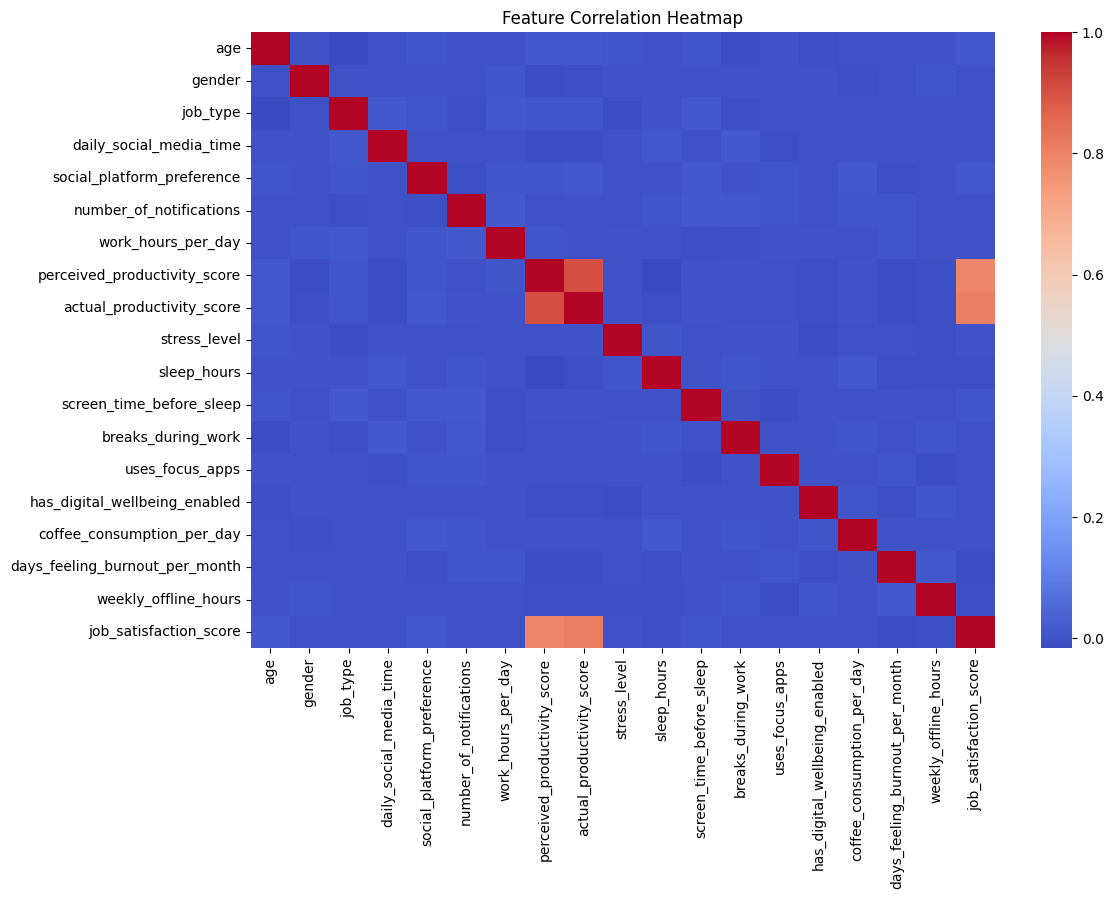

Selected Features: ['age', 'gender', 'job_type', 'daily_social_media_time', 'social_platform_preference', 'perceived_productivity_score', 'sleep_hours', 'screen_time_before_sleep', 'days_feeling_burnout_per_month', 'job_satisfaction_score']

FINAL MODEL COMPARISON
                       Model  Features Used  CV Score (R2)  Test RMSE  \
0  Random Forest (Optimized)             10       0.852636   0.697830   
1            SVR (Optimized)             10       0.827171   0.744954   

    Test R2  
0  0.849714  
1  0.828732  


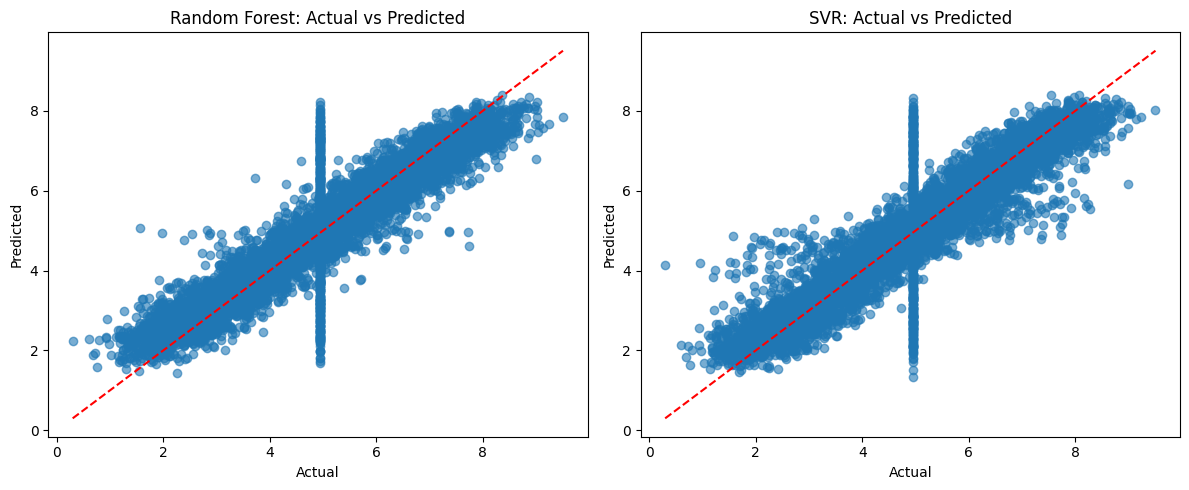

In [1]:

# IMPORT LIBRARIES


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, r2_score


# LOAD DATASET


df = pd.read_csv('/content/drive/MyDrive/AI/social_media_vs_productivity.csv')


# DATA CLEANING (NO WARNINGS)


num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical variables
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


# EDA VISUALS


plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()



# TRAIN–TEST SPLIT


X = df.drop(columns=['actual_productivity_score'])
y = df['actual_productivity_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale for NN and SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# NEURAL NETWORK REGRESSION


mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred_nn = mlp.predict(X_test_scaled)


# CLASSICAL MODELS


rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

svr = SVR()
svr.fit(X_train_scaled, y_train)


# HYPERPARAMETER TUNING


rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20]
}

svr_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'poly']
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=3,
    scoring='r2'
)
grid_rf.fit(X_train, y_train)

grid_svr = GridSearchCV(
    SVR(),
    svr_params,
    cv=3,
    scoring='r2'
)
grid_svr.fit(X_train_scaled, y_train)


# FEATURE SELECTION (TOP 10)


k = min(10, X.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)

X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", list(selected_features))


# FINAL MODELS


final_rf = grid_rf.best_estimator_
final_rf.fit(X_train_sel, y_train)
y_rf_final = final_rf.predict(X_test_sel)

final_svr = grid_svr.best_estimator_
final_svr.fit(X_train_sel, y_train)
y_svr_final = final_svr.predict(X_test_sel)


# RESULTS TABLE


results = pd.DataFrame({
    "Model": ["Random Forest (Optimized)", "SVR (Optimized)"],
    "Features Used": [k, k],
    "CV Score (R2)": [grid_rf.best_score_, grid_svr.best_score_],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_rf_final)),
        np.sqrt(mean_squared_error(y_test, y_svr_final))
    ],
    "Test R2": [
        r2_score(y_test, y_rf_final),
        r2_score(y_test, y_svr_final)
    ]
})

print("\nFINAL MODEL COMPARISON")
print(results)


# ACTUAL vs PREDICTED SCATTER PLOTS


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_rf_final, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_svr_final, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("SVR: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()


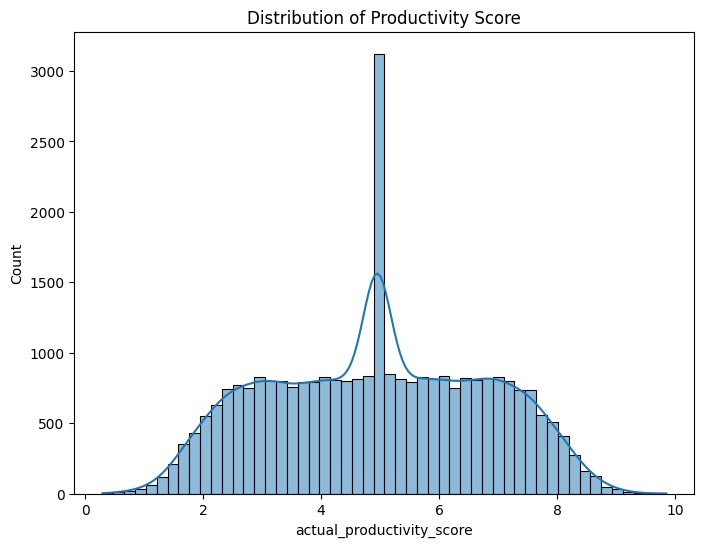

In [2]:
# Target distribution
plt.figure(figsize=(8, 6))
sns.histplot(df['actual_productivity_score'], kde=True)
plt.title("Distribution of Productivity Score")
plt.show()